In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

kb = 8.617333e-2  # meV/K

def fermi(E, kbT):
    return expit(-E / kbT)


def get_energies(data_p, data_m, phi):
    """Get energies for a given phi using the provided datasets"""
    phi_arr = data_p[:, 0]
    idx = np.argmin(np.abs(phi_arr - phi))
    E_p = data_p[idx, 1:]
    E_p = E_p[~np.isnan(E_p)]
    E_m = data_m[idx, 1:]
    E_m = E_m[~np.isnan(E_m)]
    return np.concatenate([E_p, E_m])

def free_energy(data_p, data_m, phi, T):
    """
    F(phi, T) = -kbT * sum_n ln(1 + exp(-E_n/kbT))
    Using identity: ln(1+e^{-x}) = -ln(2) + ln(2) + ln(1+e^{-x})
    But using cosh form for numerical stability: ln(2+2cosh(E_n/kbT)) = ln(2) + ln(1+cosh(E_n/kbT))
    """
    kbT = kb * T
    E_all = get_energies(data_p, data_m, phi)
    # Using the identity: ln(1+e^{-x}) = ln(2) + ln(cosh(x/2)) - x/2
    # But the cosh form is more stable: ln(2+2cosh(E/kbT)) = ln(2) + ln(1+cosh(E/kbT))
    # The standard form used in your original code:
    #return -kbT * np.sum(np.log(2 + 2*np.cosh(E_all / kbT)))
    return -kbT * np.sum(np.log(1 + np.exp(-E_all / kbT)))

def entropy(data_p, data_m, phi, T, dT=1e-6):
    """
    S = -dF/dT
    Calculate entropy from free energy using central finite difference
    """
    F_plus = free_energy(data_p, data_m, phi, T + dT)
    F_minus = free_energy(data_p, data_m, phi, T - dT)
    return -(F_plus - F_minus) / (2 * dT)

def internal_energy(data_p, data_m, phi, T):
    """
    U = F + TS
    Alternatively: U = sum_n f_n * E_n
    """
    F = free_energy(data_p, data_m, phi, T)
    S = entropy(data_p, data_m, phi, T)
    return F + T * S

# Alternative implementation if you prefer the direct sum:
def internal_energy_direct(data_p, data_m, phi, T):
    """
    U = sum_n f_n * E_n
    Direct calculation from Fermi distribution
    """
    kbT = kb * T
    E_all = get_energies(data_p, data_m, phi)
    f = fermi(E_all, kbT)
    return np.sum(f * E_all)


def stirling(data_p, data_m, data_p2, data_m2, phi1, phi2, Dv1, Dv2, Tc, Th):
    """
    Stirling cycle:
    A(phi1, Dv1, Th) -> B(phi2, Dv2, Th) isothermal
    B -> C(phi2, Dv2, Tc) isochoric
    C -> D(phi1, Dv1, Tc) isothermal
    D -> A isochoric
    """
    # State A (phi1, Dv1, Th)
    F_A = free_energy(data_p, data_m, phi1, Th)
    S_A = entropy(data_p, data_m, phi1, Th)
    U_A = internal_energy(data_p, data_m, phi1, Th)

    # State B (phi2, Dv2, Th)
    F_B = free_energy(data_p2, data_m2, phi2, Th)
    S_B = entropy(data_p2, data_m2, phi2, Th)
    U_B = internal_energy(data_p2, data_m2, phi2, Th)

    # State C (phi2, Dv2, Tc)
    F_C = free_energy(data_p2, data_m2, phi2, Tc)
    S_C = entropy(data_p2, data_m2, phi2, Tc)
    U_C = internal_energy(data_p2, data_m2, phi2, Tc)

    # State D (phi1, Dv1, Tc)
    F_D = free_energy(data_p, data_m, phi1, Tc)
    S_D = entropy(data_p, data_m, phi1, Tc)
    U_D = internal_energy(data_p, data_m, phi1, Tc)

    # Rest of the function remains the same...

    # Stroke 1: hot isothermal (A -> B)
    W1 = -(F_B - F_A)
    Qh1 = Th * (S_B - S_A)

    # Stroke 2: isochoric (B -> C)
    Qc2 = U_C - U_B

    # Stroke 3: cold isothermal (C -> D)
    W3 = -(F_D - F_C)
    Qc3 = Tc * (S_D - S_C)

    # Stroke 4: isochoric (D -> A)
    Qh4 = U_A - U_D

    WT = W1 + W3
    Qhot = Qh1 + Qh4
    Qcold = Qc2 + Qc3

    return W1, W3, WT, Qh1, Qh4, Qhot, Qc2, Qc3, Qcold

def stirling_sweep(data_p, data_m, data_p2, data_m2, phi1, Dv1, Dv2, Tc, Th, n_phi2=600):
    """
    Sweep phi2 for fixed phi1, Dv1, Dv2, Tc, Th
    """
    phi2_arr = np.linspace(0, 2*np.pi, n_phi2)
    WT_arr = np.zeros(n_phi2)
    Qhot_arr = np.zeros(n_phi2)
    Qcold_arr = np.zeros(n_phi2)
    COP_arr = np.zeros(n_phi2)

    for i, phi2 in enumerate(phi2_arr):
        _, _, WT, _, _, Qhot, _, _, Qcold = stirling(
            data_p, data_m, data_p2, data_m2, phi1, phi2, Dv1, Dv2, Tc, Th)
        WT_arr[i] = WT
        Qhot_arr[i] = Qhot
        Qcold_arr[i] = Qcold

        if Qhot > 0 and Qcold < 0 and WT < 0:
            COP_arr[i] = abs(Qcold) / abs(WT)
        else:
            COP_arr[i] = np.nan

    return phi2_arr, Qhot_arr, Qcold_arr, WT_arr, COP_arr


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import brentq
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
def stirling_heatmap(data_p, data_m, data_p2, data_m2, Dv1, Dv2, Tc, Th, n=80, save=False):
    """
    Create a heatmap of WT as a function of phi1 and phi2 with fixed Dv1 and Dv2.

    Parameters:
    -----------
    data_p, data_m : arrays for Dv=0
    data_p2, data_m2 : arrays for Dv=0.06
    Dv1, Dv2 : values for states A/D and B/C respectively
    Tc, Th : temperatures
    n : grid resolution
    save : whether to save the figure
    """
    phi_grid = np.linspace(0, 2*np.pi, n)
    WT_map = np.full((n, n), np.nan)
    Qhot_map = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)

    for i, phi1 in enumerate(phi_grid):
        for j, phi2 in enumerate(phi_grid):
            _, _, WT, _, _, Qhot, _, _, Qcold = stirling(
                data_p, data_m, data_p2, data_m2, phi1, phi2, Dv1, Dv2, Tc, Th)
            Qhot_map[i, j] = Qhot
            Qcold_map[i, j] = Qcold
            WT_map[i, j] = WT*1000

            # Regime classification
            if Qhot > 0 and Qcold < 0 and WT > 0: regime_map[i, j] = 1      # Heat pump
            elif Qhot < 0 and Qcold > 0 and WT < 0: regime_map[i, j] = 2    # Refrigerator
            elif Qhot > 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 3    # Cold pump
            elif Qhot < 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 4    # Heater

    WT_masked = np.where(regime_map > 0, WT_map, np.nan)
    # Get min and max values for the colorbar (excluding NaN)
    vmin = np.nanmin(WT_masked)
    vmax = np.nanmax(WT_masked)

    # Use TwoSlopeNorm to put white at zero
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(phi_grid, phi_grid, WT_masked,
                       cmap="RdBu_r", norm=norm, shading="auto")

    # Add colorbar with appropriate ticks
    cbar = plt.colorbar(im, ax=ax, label=r"$W_T$  ($\mu$eV)")
    cbar.ax.set_ylabel(r'$W_T$  ($\mu$eV)', fontsize=40, color='blue')  # Increase label size
    cbar.ax.tick_params(labelsize=25)  # Increase tick label size

    # Create 2 equidistant ticks below zero and 2 above zero
    # Negative side (from vmin to 0)
    negative_ticks = np.linspace(vmin, 0, 3)  # gives 3 points: vmin, midpoint, 0
    negative_ticks = negative_ticks[:-1]  # remove 0 to avoid duplication, keep 2 ticks

    # Positive side (from 0 to vmax)
    positive_ticks = np.linspace(0, vmax, 3)  # gives 3 points: 0, midpoint, vmax
    positive_ticks = positive_ticks[1:]  # remove 0 to avoid duplication, keep 2 ticks

    # Combine all ticks (including 0)
    ticks = np.concatenate([negative_ticks, [0], positive_ticks])
    cbar.set_ticks(ticks)

    # Optional: Add a white line at zero to emphasize it
    cbar.ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    # For axis ticks
    ax.tick_params(axis='both', labelsize=30)  # Increase axis tick label size

    cs_kw = dict(linewidths=2)
    ax.contour(phi_grid, phi_grid, WT_map, levels=[0], colors="black", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qhot_map, levels=[0], colors="crimson",
               linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qcold_map, levels=[0], colors="purple",
               linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0], [0], color="black", lw=2, ls="-", label=r"$W_T=0$"),
        Line2D([0], [0], color="crimson", lw=2, ls="--", label=r"$Q_\mathrm{hot}=0$"),
        Line2D([0], [0], color="purple", lw=2, ls="--", label=r"$Q_\mathrm{cold}=0$"),
    ], fontsize=20, loc="upper center")

    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tlbls = ["0", "π/2", "π", "3π/2", "2π"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tlbls)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tlbls)
    ax.set_xlabel(r"$\phi_2$", fontsize=40)
    ax.set_ylabel(r"$\phi_1$", fontsize=40)
    #ax.set_title(
    #    fr"$W_T(\phi_1,\phi_2)$ — $Dv_1$={Dv1}, $Dv_2$={Dv2} meV, $T_c$={Tc} K, $T_h$={Th} K",
    #    fontsize=13)
    plt.tight_layout()


    plt.savefig(f"3Fig4c.png", dpi=150, bbox_inches="tight")

    plt.show()
    return phi_grid, WT_masked, regime_map


def ALL_case2_heatmap(data_p, data_m, data_p2, data_m2, Dv1, Dv2, Tc, Th, n=80, save=False):
    """
    Create a combined heatmap showing all three regimes with different colormaps:
    1. Heat engine: eta/eta_Carnot (plasma colormap)
    2. Refrigerator: COP/COP_Carnot (cool colormap)
    3. Cold pump: COP = |Qcold|/|WT| (hot_r colormap, capped at 50)

    Parameters
    ----------
    data_p, data_m : arrays for Dv=0
    data_p2, data_m2 : arrays for Dv=0.06
    Dv1, Dv2 : Dv values for states A/D and B/C respectively
    Tc, Th : temperatures
    n : grid resolution
    save : whether to save the figure
    """
    eta_C = 1 - Tc / Th
    COP_C = Tc / (Th - Tc)
    phi_grid = np.linspace(0, 2*np.pi, n)

    # Initialize maps
    combined_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)
    WT_map = np.full((n, n), np.nan)
    Qhot_map = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)

    # Store values for each regime separately
    engine_values = np.full((n, n), np.nan)
    refrigerator_values = np.full((n, n), np.nan)
    coldpump_values = np.full((n, n), np.nan)

    print("Computing combined eta/COP heatmap...")
    for i, phi1 in enumerate(phi_grid):
        if i % 10 == 0:
            print(f"  row {i}/{n}")
        for j, phi2 in enumerate(phi_grid):
            _, _, WT, _, _, Qhot, _, _, Qcold = stirling(
                data_p, data_m, data_p2, data_m2, phi1, phi2, Dv1, Dv2, Tc, Th)

            WT_map[i, j] = WT
            Qhot_map[i, j] = Qhot
            Qcold_map[i, j] = Qcold

            # Heat Engine regime: Qhot > 0, Qcold < 0, WT > 0
            if Qhot > 0 and Qcold < 0 and WT > 0:
                regime_map[i, j] = 1
                engine_values[i, j] = (WT / Qhot) / eta_C
                combined_map[i, j] = engine_values[i, j]

            # Refrigerator regime: Qhot < 0, Qcold > 0, WT < 0
            elif Qhot < 0 and Qcold > 0 and WT < 0:
                regime_map[i, j] = 2
                refrigerator_values[i, j] = (abs(Qcold) / abs(WT)) / COP_C
                combined_map[i, j] = refrigerator_values[i, j]

            # Cold Pump regime: Qhot > 0, Qcold < 0, WT < 0
            elif Qhot > 0 and Qcold < 0 and WT < 0:
                regime_map[i, j] = 3
                coldpump_values[i, j] = min(abs(Qcold) / abs(WT), 50)
                combined_map[i, j] = coldpump_values[i, j]

    # Create RGB image with white for invalid regions
    rgb_image = np.ones((n, n, 3))  # Start with white (1,1,1)

    # Get colormaps
    plasma_cmap = plt.cm.plasma
    cool_cmap = plt.cm.cool
    hot_cmap = plt.cm.hot_r

    engine_mask = (regime_map == 1)
    ref_mask = (regime_map == 2)
    pump_mask = (regime_map == 3)

    # Store colorbar info
    colorbar_info = {}

    if np.any(engine_mask):
        engine_vals = engine_values[engine_mask]
        vmin_engine = 0
        vmax_engine = np.nanmax(engine_vals)
        engine_norm = plt.Normalize(vmin=vmin_engine, vmax=vmax_engine)(engine_vals)
        engine_colors = plasma_cmap(engine_norm)
        rgb_image[engine_mask] = engine_colors[:, :3]
        colorbar_info['engine'] = {
            'vmin': vmin_engine,
            'vmax': vmax_engine,
            'cmap': plasma_cmap,
            'label': r"HE: $\eta_{\mathrm{HE}}/\eta_{\mathrm{c}}$"
        }
        print(f"HE range: {vmin_engine:.3f} to {vmax_engine:.3f}")

    if np.any(ref_mask):
        ref_vals = refrigerator_values[ref_mask]
        vmin_ref = 0
        vmax_ref = np.nanmax(ref_vals)
        ref_norm = plt.Normalize(vmin=vmin_ref, vmax=vmax_ref)(ref_vals)
        ref_colors = cool_cmap(ref_norm)
        rgb_image[ref_mask] = ref_colors[:, :3]
        colorbar_info['refrigerator'] = {
            'vmin': vmin_ref,
            'vmax': vmax_ref,
            'cmap': cool_cmap,
            'label': r"RE: $\mathrm{COP_{\mathrm{RE}}}/\mathrm{COP}_{\mathrm{c}}$"
        }
        print(f"Refrigerator range: {vmin_ref:.3f} to {vmax_ref:.3f}")

    if np.any(pump_mask):
        pump_vals = coldpump_values[pump_mask]
        vmin_pump = 0
        vmax_pump = 50  # Capped at 50
        pump_norm = plt.Normalize(vmin=vmin_pump, vmax=vmax_pump)(pump_vals)
        pump_colors = hot_cmap(pump_norm)
        rgb_image[pump_mask] = pump_colors[:, :3]
        colorbar_info['coldpump'] = {
            'vmin': vmin_pump,
            'vmax': vmax_pump,
            'cmap': hot_cmap,
            'label': r"CP: $\mathrm{COP_{\mathrm{CP}}} $"
        }
        print(f"Cold Pump range: {vmin_pump:.3f} to {vmax_pump:.3f}")

    # Create figure with specific size
    fig = plt.figure(figsize=(10, 8))

    # Create main plot axis (positioned on the left)
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])  # This makes the main plot square-like

    # Create three separate axes for colorbars on the right
    cbar_width = 0.03
    cbar_spacing = 0.05
    cbar_start_x = 0.73

    # Calculate positions for three colorbars
    cbar_height = 0.24
    total_height = 3 * cbar_height + 2 * cbar_spacing
    start_y = (0.8 - total_height) / 2 + 0.05

    # Top colorbar (Heat Engine)
    cbar_ax1 = fig.add_axes([cbar_start_x, start_y + 2*(cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Middle colorbar (Refrigerator)
    cbar_ax2 = fig.add_axes([cbar_start_x, start_y + (cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Bottom colorbar (Cold Pump)
    cbar_ax3 = fig.add_axes([cbar_start_x, start_y,
                             cbar_width, cbar_height])

    # Display the RGB image in the main plot
    im = ax.imshow(rgb_image, extent=[0, 2*np.pi, 0, 2*np.pi],
                   origin='lower', aspect='equal')

    # Add contour lines
    cs_kw = dict(linewidths=2)
    ax.contour(phi_grid, phi_grid, WT_map, levels=[0],
               colors="white", linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qhot_map, levels=[0],
               colors="red", linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qcold_map, levels=[0],
               colors="blue", linestyles="--", **cs_kw)


    if 'engine' in colorbar_info:
        engine_norm = plt.Normalize(colorbar_info['engine']['vmin'],
                                    colorbar_info['engine']['vmax'])
        engine_sm = plt.cm.ScalarMappable(cmap=colorbar_info['engine']['cmap'],
                                          norm=engine_norm)
        engine_sm.set_array([])
        cbar1 = plt.colorbar(engine_sm, cax=cbar_ax1, orientation='vertical')
        cbar1.set_label(colorbar_info['engine']['label'], fontsize=20, color="blue")
        cbar1.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['engine']['vmin']
        vmax = colorbar_info['engine']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar1.set_ticks(ticks)
        # Optional: format ticks to show 1 decimal place
        cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'refrigerator' in colorbar_info:
        ref_norm = plt.Normalize(colorbar_info['refrigerator']['vmin'],
                                 colorbar_info['refrigerator']['vmax'])
        ref_sm = plt.cm.ScalarMappable(cmap=colorbar_info['refrigerator']['cmap'],
                                       norm=ref_norm)
        ref_sm.set_array([])
        cbar2 = plt.colorbar(ref_sm, cax=cbar_ax2, orientation='vertical')
        cbar2.set_label(colorbar_info['refrigerator']['label'], fontsize=20, color="blue")
        cbar2.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['refrigerator']['vmin']
        vmax = colorbar_info['refrigerator']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar2.set_ticks(ticks)
        cbar2.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'coldpump' in colorbar_info:
        pump_norm = plt.Normalize(colorbar_info['coldpump']['vmin'],
                                  colorbar_info['coldpump']['vmax'])
        pump_sm = plt.cm.ScalarMappable(cmap=colorbar_info['coldpump']['cmap'],
                                        norm=pump_norm)
        pump_sm.set_array([])
        cbar3 = plt.colorbar(pump_sm, cax=cbar_ax3, orientation='vertical')
        cbar3.set_label(colorbar_info['coldpump']['label'], fontsize=20, color="blue")
        cbar3.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['coldpump']['vmin']
        vmax = colorbar_info['coldpump']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar3.set_ticks(ticks)
        cbar3.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # Legend (placed inside the main plot)
    legend_elements = [
        Line2D([0], [0], color="white", lw=2, ls="--", label=r"$W_T = 0$"),
        Line2D([0], [0], color="red", lw=2, ls="--", label=r"$Q_{\mathrm{hot}} = 0$"),
        Line2D([0], [0], color="blue", lw=2, ls="--", label=r"$Q_{\mathrm{cold}} = 0$")
    ]

    ax.legend(handles=legend_elements, fontsize=20, loc="upper center")

    # Set ticks
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tlbls = ["0", "π/2", "π", "3π/2", "2π"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tlbls)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tlbls)
    ax.set_xlabel(r"$\phi_2$", fontsize=40)
    ax.set_ylabel(r"$\phi_1$", fontsize=40)
    ax.tick_params(axis='both', labelsize=30)

    # Add title (commented out to match other functions)
    #ax.set_title(
    #    fr"Combined Performance Maps — $Dv_1={Dv1}$, $Dv_2={Dv2}$ meV, "
    #    fr"$T_c={Tc}$ K, $T_h={Th}$ K",
    #    fontsize=14, pad=20)

    plt.tight_layout()

    plt.savefig(f"3Fig4d.png", dpi=150, bbox_inches="tight")

    plt.show()

    return (phi_grid, combined_map, regime_map, WT_map, Qhot_map, Qcold_map,
            engine_values, refrigerator_values, coldpump_values)

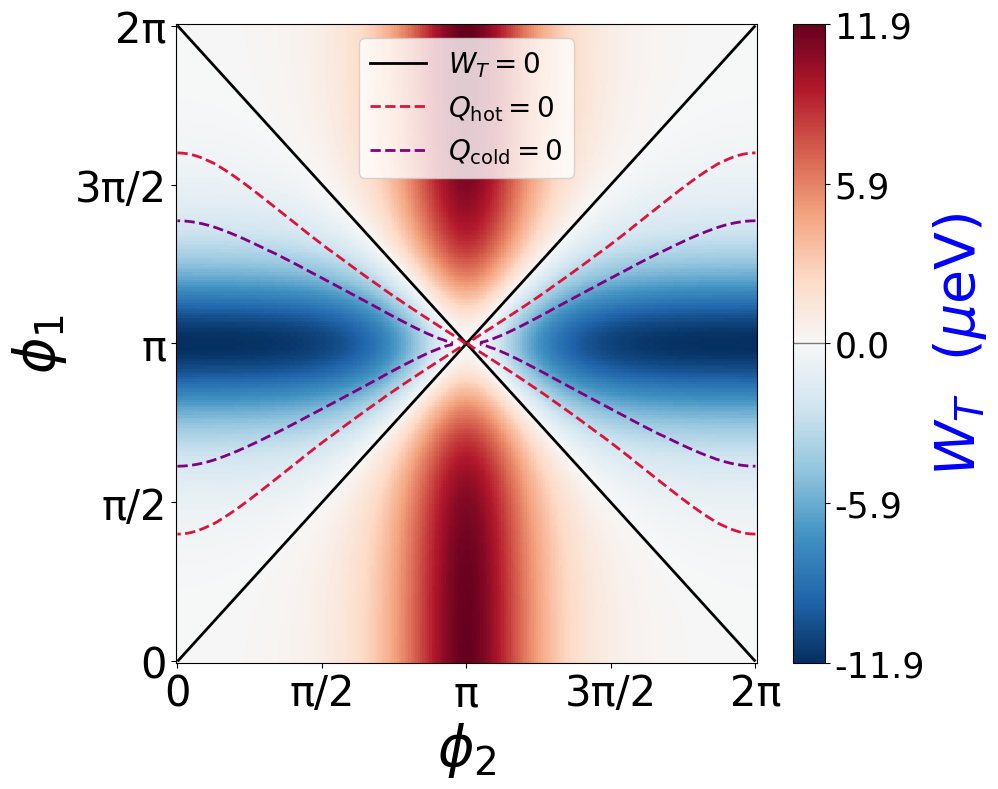

Computing combined eta/COP heatmap...
  row 0/250
  row 10/250
  row 20/250
  row 30/250
  row 40/250
  row 50/250
  row 60/250
  row 70/250
  row 80/250
  row 90/250
  row 100/250
  row 110/250
  row 120/250
  row 130/250
  row 140/250
  row 150/250
  row 160/250
  row 170/250
  row 180/250
  row 190/250
  row 200/250
  row 210/250
  row 220/250
  row 230/250
  row 240/250
HE range: 0.000 to 0.997
Refrigerator range: 0.000 to 0.967
Cold Pump range: 0.000 to 50.000


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_21047/2134734993.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


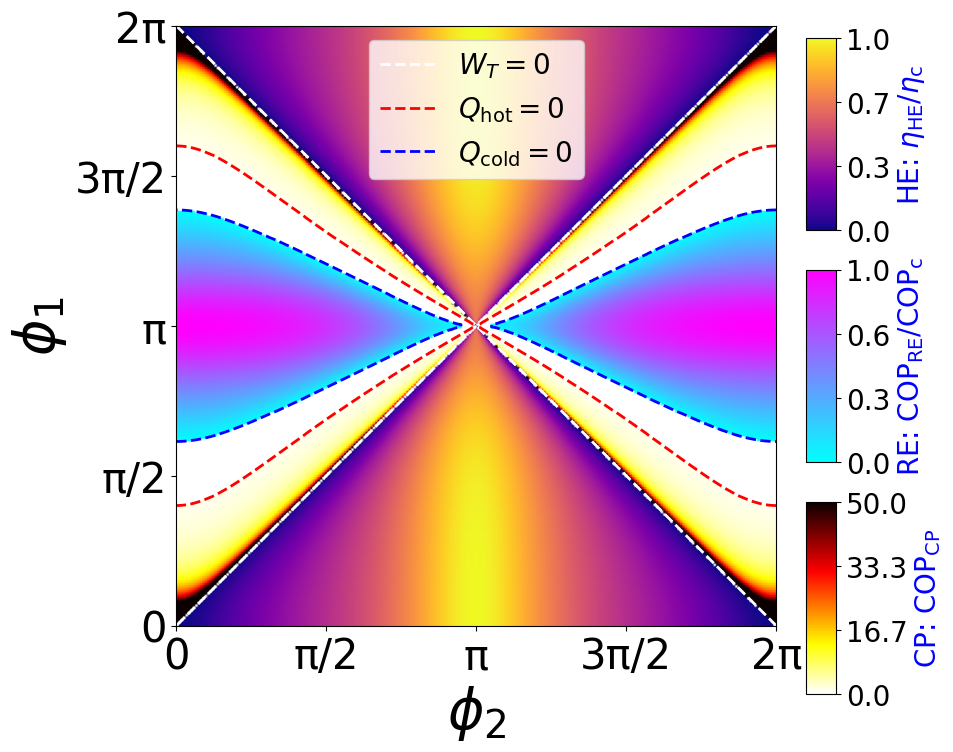

(array([0.        , 0.02523368, 0.05046735, 0.07570103, 0.1009347 ,
        0.12616838, 0.15140206, 0.17663573, 0.20186941, 0.22710308,
        0.25233676, 0.27757044, 0.30280411, 0.32803779, 0.35327146,
        0.37850514, 0.40373881, 0.42897249, 0.45420617, 0.47943984,
        0.50467352, 0.52990719, 0.55514087, 0.58037455, 0.60560822,
        0.6308419 , 0.65607557, 0.68130925, 0.70654293, 0.7317766 ,
        0.75701028, 0.78224395, 0.80747763, 0.83271131, 0.85794498,
        0.88317866, 0.90841233, 0.93364601, 0.95887969, 0.98411336,
        1.00934704, 1.03458071, 1.05981439, 1.08504807, 1.11028174,
        1.13551542, 1.16074909, 1.18598277, 1.21121644, 1.23645012,
        1.2616838 , 1.28691747, 1.31215115, 1.33738482, 1.3626185 ,
        1.38785218, 1.41308585, 1.43831953, 1.4635532 , 1.48878688,
        1.51402056, 1.53925423, 1.56448791, 1.58972158, 1.61495526,
        1.64018894, 1.66542261, 1.69065629, 1.71588996, 1.74112364,
        1.76635732, 1.79159099, 1.81682467, 1.84

In [5]:
# ----------------------------------------------------------------------------
# MATBG CASE
# ----------------------------------------------------------------------------

data_p = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
data_m = np.loadtxt("ABS_MATBG_taum_Dv00.dat")
data_p2 = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
data_m2 = np.loadtxt("ABS_MATBG_taum_Dv00.dat")

# ----------------------------------------------------------------------------
# AABLG CASE
# ----------------------------------------------------------------------------

#data_p = np.loadtxt("ABS_AABLG_taup_Dv0000_NEW.dat")
#data_m = np.loadtxt("ABS_AABLG_taum_Dv0000_NEW.dat")
#data_p2 = np.loadtxt("ABS_AABLG_taup_Dv0000_NEW.dat")
#data_m2 = np.loadtxt("ABS_AABLG_taum_Dv0000_NEW.dat")


# WORK OUTPUT
phi_grid, WT_masked, regime_map = stirling_heatmap(
    data_p, data_m, data_p2, data_m2,
    Dv1=0, Dv2=0.0,
    Tc=0.05, Th=0.10,
    n=250, save=False
)

# PERFORMANCE METRIC

ALL_case2_heatmap(
    data_p, data_m, data_p2, data_m2,
    Dv1=0, Dv2=0.0, Tc=0.05, Th=0.10,
    n=250, save=False
)